In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
base_path = Path(".") # change to path folder with data 


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

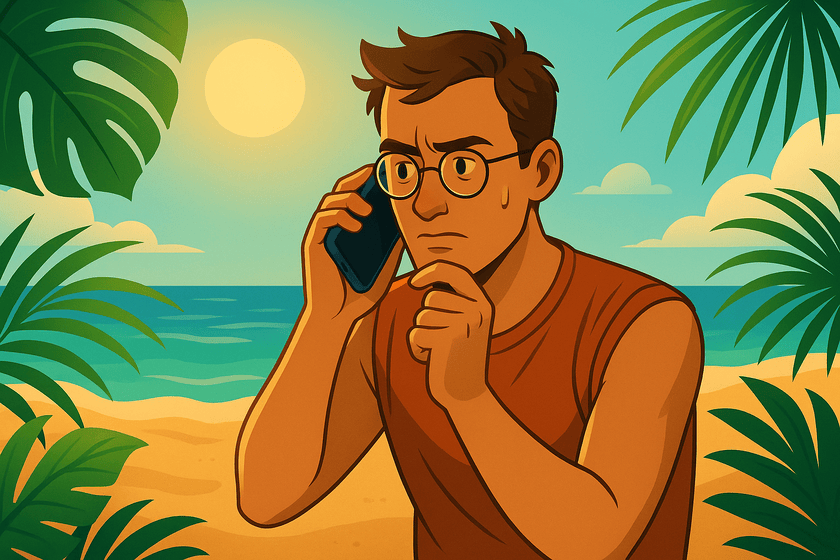

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [2]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [3]:
titanic_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

38% osob przezylo

In [4]:
titanic_df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [5]:
titanic_df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [6]:
titanic_df.shape

(891, 11)

891 danych o pasazerach

In [7]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


brakujace dane dla age, fare, cabin

In [8]:
titanic_df.describe(include='all')

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,793.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,33.123938,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,51.578312,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.925000,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.500000,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN


dlaczego jest tylko 681 unique ticketów?
dlaczego tylko 147 unique kabin?
dlaczego ktoś ma wiek 0.42 float, a nie int?
dlaczego ktoś nie zapłacił nic za podróz? byla to obsługa?

In [9]:
titanic_df.duplicated().sum()

np.int64(0)

brak zduplikowanych wierszy

In [10]:
for col in titanic_df.columns:
    print(f'\n{col}:')
    print(titanic_df[col].value_counts(dropna=False))


Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Name:
Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Age:
Age
NaN      177
24.00     30
22.00     27
18.00     26
28.00     25
        ... 
24.50      1
0.67       1
0.42       

Imiona mają tytuły: Mr, Mrs., Miss. etc, moze mają one znaczenie?
Wiek ma więcej wartości float, niz wczesniej zauwazone 0.42.
SibSp i Parch mają mało przykładów dla niektórych wartości, co sprawia ze korzystanie z tych grup moze być niemiarodajne.
Czy te literki na nazwach biletów coś oznaczają?
Niektórzy za bilet płacili 13.8583, części groszy?
Numery Kabin mają literki, moze coś one oznaczają? piętro?
Niektóre osoby mają kilka kabin.
Czy to oznacza ze na jeden bilet plynie kilka osob? to oznaczaloby ze fare to jest za kilka osob

Teraz zajmijmy się tymi wszystkimi pytaniami:

--Brakujące dane:

age - zimputujemy dane, moze być wazne

fare - zimputujemy, braków jest mało

cabin - bardzo duzo brakujacych danych

--Age

ułamkowy Age, to po prostu część roku, jakaś informacja


In [11]:
titanic_df['Ticket'].value_counts().head(20)

Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
19950           4
W./C. 6608      4
4133            4
LINE            4
113781          4
17421           4
PC 17757        4
113760          4
2666            4
347742          3
Name: count, dtype: int64

Duplikaty numery biletów, to prawdopodobnie kilka osób podrózujących jednym biletem. 
Zatem przydatna moze być informacja, z iloma osobami on podruzuje:

In [12]:
titanic_df['TicketGroupSize'] = (
    titanic_df.groupby('Ticket')['Ticket'].transform('count')
)   

Prefiksy biletów zalezą od miejsc w ktorych byly sprzedawane prawodopodobnie.
Moze sie przydadza, wydziele je:

In [13]:
titanic_df['TicketPrefix'] = (
    titanic_df['Ticket']
    .str.replace(r'\d+', '', regex=True)
    .str.replace('.', '', regex=False)
    .str.replace('/', '', regex=False)
    .str.strip()
    .replace('', 'NONE')
)

Fare

Nie wiem dlaczego niektórzy płacili 0, zostawmy to

In [14]:
titanic_df[titanic_df['Fare'] == 0][
    ['Name', 'Pclass', 'Ticket', 'Cabin', 'Embarked', 'Fare', 'TicketGroupSize', 'TicketPrefix']
]

,Name,Pclass,Ticket,Cabin,Embarked,Fare,TicketGroupSize,TicketPrefix
PassengerId,,,,,,,,
180,"Leonard, Mr. Lionel",3,LINE,NaN,S,0.0,4,LINE
272,"Tornquist, Mr. William Henry",3,LINE,NaN,S,0.0,4,LINE
278,"Parkes, Mr. Francis ""Frank""",2,239853,NaN,S,0.0,3,NONE
303,"Johnson, Mr. William Cahoone Jr",3,LINE,NaN,S,0.0,4,LINE
414,"Cunningham, Mr. Alfred Fleming",2,239853,NaN,S,0.0,3,NONE
467,"Campbell, Mr. William",2,239853,NaN,S,0.0,3,NONE
482,"Frost, Mr. Anthony Wood ""Archie""",2,239854,NaN,S,0.0,1,NONE
598,"Johnson, Mr. Alfred",3,LINE,NaN,S,0.0,4,LINE
634,"Parr, Mr. William Henry Marsh",1,112052,NaN,S,0.0,1,NONE


Niektórzy płacili 7.9250, poniewaz taki kiedys system mial system walutowy w uk

A czy fare, to cena za jeden bilet? Czy bilety wszystkich podruzujących?

In [15]:
titanic_df.groupby('Ticket').agg(
    passengers=('Ticket', 'size'),
    fare=('Fare', 'first')
).sort_values('passengers', ascending=False)

,passengers,fare
Ticket,,
1601,7,56.4958
CA. 2343,7,69.5500
347082,7,31.2750
CA 2144,6,46.9000
347088,6,27.9000
...,...,...
345572,1,17.4000
345364,1,6.2375
343276,1,8.0500


Jak widać ceny biletów, gdzie jest wielu pasazerów są wysokie, co sugeruje ze to jest cena za jeden zbiorowy bilet. Stwórzmy zatem wskaźnik ceny biletu za daną osobę.

In [16]:
titanic_df['FarePerPerson'] = (
    titanic_df['Fare'] / titanic_df['TicketGroupSize']
)

Numery kabin, wydobądźmy najpierw numer piętra

In [17]:
titanic_df['Deck'] = titanic_df['Cabin'].str[0]
titanic_df['Deck'] = titanic_df['Deck'].fillna('Unknown')

Dlaczego jest tyle unknown? 

In [18]:
pd.crosstab(
    titanic_df['Pclass'],
    titanic_df['Cabin'].notna(),
    normalize='index'
)

Cabin,False,True
Pclass,,
1,0.185185,0.814815
2,0.913043,0.086957
3,0.975560,0.024440


Okazuje się ze te unknown, to głównie pasazerowie 2 i 3 klasy. To moze być przydatna informacja:

In [19]:
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)

Name - wydzielmy te tytuły

In [20]:
titanic_df['Title'] = (
    titanic_df['Name']
    .str.extract(r',\s*([^.]*)\.')[0]
    .str.strip()
)

In [21]:
titanic_df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Jezeli chodzi o liczbe relative na statkow, moze byc to przydatna informacja. Połączmy obie kolumny: 

In [22]:
titanic_df['FamilySize'] = (
    titanic_df['SibSp']
    + titanic_df['Parch']
    + 1 #pasazer jest czlonkiem rodziny
)

Embarked - 2 brakujące wartości, zobaczmy je:

In [23]:
titanic_df[titanic_df['Embarked'].isna()].head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,TicketGroupSize,TicketPrefix,FarePerPerson,Deck,HasCabin,Title,FamilySize
PassengerId,,,,,,,,,,,,,,,,,,
62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,2,NONE,40.0,B,1,Miss,1
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,2,NONE,40.0,B,1,Mrs,1


Te same bilety

In [24]:
similar = titanic_df[
    (titanic_df['Pclass'] == 1) &
    (titanic_df['Sex'] == 'female') &
    (titanic_df['Fare'].between(70, 90)) &
    (titanic_df['Cabin'].str.startswith('B', na=False))
]

similar[['Name', 'Fare', 'Cabin', 'Embarked']]

,Name,Fare,Cabin,Embarked
PassengerId,,,,
62,"Icard, Miss. Amelie",80.0,B28,NaN
505,"Maioni, Miss. Roberta",86.5,B79,S
541,"Crosby, Miss. Harriet R",71.0,B22,S
760,"Rothes, the Countess. of (Lucy Noel Martha Dye...",86.5,B77,S
830,"Stone, Mrs. George Nelson (Martha Evelyn)",80.0,B28,NaN


Podobni pasazerowie, maja embarked S, zatem imputuje S

In [25]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('S')

In [26]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,TicketGroupSize,TicketPrefix,FarePerPerson,Deck,HasCabin,Title,FamilySize
PassengerId,,,,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,A,7.2500,Unknown,0,Mr,2
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,PC,71.2833,C,1,Mrs,2
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,STONO,7.9250,Unknown,0,Miss,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,NONE,26.5500,C,1,Mrs,2
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,NONE,8.0500,Unknown,0,Mr,1


usuńmy niepotrzebne juz kolumny - istotne informacje wyciagnalem do innych kolumn

In [27]:
titanic_df =titanic_df.drop(
    columns=['Name', 'Ticket', 'Cabin']
)

więc co dotychczas zrobiłem:

- uzupełniłem braki w embarked

- kolumna ticket group size

- kolumna ticket prefix

- kolumna fareperperson

- kolumna deck

- kolumna hascabin

- kolumna title

- kolumna familysize

potencjalnie mozna lepiej pogrupowac wartosci w kolumnach
potencjalne kolumny które mozna wydzielic:
IsAlone, Mother, Child

Zajmijmy się teraz resztą brakujących wartości: Fare i Age

In [28]:
print("Overall median Fare:", titanic_df['Fare'].median())

categorical_cols = [
    'Pclass',
    'Sex',
    'Embarked',
    'FamilySize'
]

for col in categorical_cols:
    print(f'\nFare by {col}:')
    print(
        titanic_df.groupby(col)['Fare']
        .agg(['count', 'median'])
    )

Overall median Fare: 14.5

Fare by Pclass:
        count   median
Pclass                
1         194  60.2875
2         169  14.0000
3         430   8.0500

Fare by Sex:
        count  median
Sex                  
female    282  24.075
male      511  12.275

Fare by Embarked:
          count  median
Embarked               
C           153   29.70
Q            66    7.75
S           574   13.00

Fare by FamilySize:
            count   median
FamilySize                
1             474   8.4458
2             148  26.0000
3              92  26.0000
4              25  27.7500
5              14  25.4667
6              17  29.1250
7              11  31.2750
8               5  46.9000
11              7  69.5500


sensowne wydaje się imputowanie median kombinacji Pclass i Sex

In [29]:
titanic_df['Fare'] = (
    titanic_df
    .groupby(['Pclass', 'Sex'])['Fare']
    .transform(lambda x: x.fillna(x.median()))
)

teraz spójrzmy na age

In [30]:
print("Overall median Age:", titanic_df['Age'].median())

categorical_cols = [
    'Pclass',
    'Sex',
    'Embarked',
    'FamilySize'
]

for col in categorical_cols:
    print(f'\nAge by {col}:')
    print(
        titanic_df.groupby(col)['Age']
        .agg(['count', 'median'])
    )

Overall median Age: 28.0

Age by Pclass:
        count  median
Pclass               
1         186    37.0
2         173    29.0
3         355    24.0

Age by Sex:
        count  median
Sex                  
female    261    27.0
male      453    29.0

Age by Embarked:
          count  median
Embarked               
C           130    29.0
Q            28    27.0
S           556    28.0

Age by FamilySize:
            count  median
FamilySize               
1             404    29.5
2             139    29.0
3              93    27.0
4              27    23.0
5              11    18.0
6              22    12.0
7              12     9.0
8               6    12.5
11              0     NaN


Tutaj najbardziej sensowne wydaje się imputowanie ze względu na Pclass

In [31]:
titanic_df['Age'] = titanic_df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [32]:
titanic_df['FarePerPerson'] = (
    titanic_df['Fare'] / titanic_df['TicketGroupSize']
)

In [33]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         891 non-null    int64  
 1   Pclass           891 non-null    int64  
 2   Sex              891 non-null    str    
 3   Age              891 non-null    float64
 4   SibSp            891 non-null    int64  
 5   Parch            891 non-null    int64  
 6   Fare             891 non-null    float64
 7   Embarked         891 non-null    str    
 8   TicketGroupSize  891 non-null    int64  
 9   TicketPrefix     891 non-null    str    
 10  FarePerPerson    891 non-null    float64
 11  Deck             891 non-null    str    
 12  HasCabin         891 non-null    int64  
 13  Title            891 non-null    str    
 14  FamilySize       891 non-null    int64  
dtypes: float64(3), int64(7), str(5)
memory usage: 104.5 KB


Zajmijmy się teraz kodowaniem cech kategorialnych. Mamy 

In [34]:
titanic_df.head(20)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,TicketGroupSize,TicketPrefix,FarePerPerson,Deck,HasCabin,Title,FamilySize
PassengerId,,,,,,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,1,A,7.250000,Unknown,0,Mr,2
2,1,1,female,38.0,1,0,71.2833,C,1,PC,71.283300,C,1,Mrs,2
3,1,3,female,26.0,0,0,7.9250,S,1,STONO,7.925000,Unknown,0,Miss,1
4,1,1,female,35.0,1,0,53.1000,S,2,NONE,26.550000,C,1,Mrs,2
5,0,3,male,35.0,0,0,8.0500,S,1,NONE,8.050000,Unknown,0,Mr,1
6,0,3,male,24.0,0,0,8.4583,Q,1,NONE,8.458300,Unknown,0,Mr,1
7,0,1,male,54.0,0,0,51.8625,S,1,NONE,51.862500,E,1,Mr,1
8,0,3,male,2.0,3,1,21.0750,S,4,NONE,5.268750,Unknown,0,Master,5
9,1,3,female,27.0,0,2,12.4750,S,3,NONE,4.158333,Unknown,0,Mrs,3


In [35]:
titanic_df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [36]:
titanic_df['TicketPrefix'].value_counts()

TicketPrefix
NONE          661
PC             60
CA             41
A              28
STONO          18
SOTONOQ        15
WC             10
SCPARIS         7
SOC             6
C               5
FCC             5
SCParis         4
LINE            4
PP              3
WEP             3
SOPP            3
SWPP            2
PPP             2
SCAH            2
SOTONO          2
SCA             1
SP              1
SOP             1
Fa              1
SCOW            1
SC              1
AS              1
SCAH Basle      1
FC              1
CASOTON         1
Name: count, dtype: int64

bardzo duzo pojedynczych danych, źle

In [37]:
title_counts = titanic_df['Title'].value_counts()

rare_titles = title_counts[title_counts < 10].index

titanic_df['Title'] = titanic_df['Title'].replace(
    rare_titles,
    'Rare'
)

prefix_counts = titanic_df['TicketPrefix'].value_counts()

rare_prefixes = prefix_counts[prefix_counts < 10].index

titanic_df['TicketPrefix'] = titanic_df['TicketPrefix'].replace(
    rare_prefixes,
    'Rare'
)

In [38]:
titanic_clean = titanic_df.copy()

In [39]:
titanic_df['Sex'] = titanic_df['Sex'].map({
    'male': 0,
    'female': 1
})

In [40]:
categorical_cols = [
    'Embarked',
    'TicketPrefix',
    'Deck',
    'Title'
]

titanic_df = pd.get_dummies(
    titanic_df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [41]:
titanic_df.columns.tolist()

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'TicketGroupSize',
 'FarePerPerson',
 'HasCabin',
 'FamilySize',
 'Embarked_Q',
 'Embarked_S',
 'TicketPrefix_CA',
 'TicketPrefix_NONE',
 'TicketPrefix_PC',
 'TicketPrefix_Rare',
 'TicketPrefix_SOTONOQ',
 'TicketPrefix_STONO',
 'TicketPrefix_WC',
 'Deck_B',
 'Deck_C',
 'Deck_D',
 'Deck_E',
 'Deck_F',
 'Deck_G',
 'Deck_T',
 'Deck_Unknown',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare']

Podsumowując, tak zakodowałem:

| Feature | Encoding |
|---|---|
| `Sex` | Binary encoding |
| `Embarked` | One-hot encoding |
| `Deck` | One-hot encoding |
| `Title` | Rare grouping + one-hot encoding |
| `TicketPrefix` | Rare grouping + one-hot encoding |

Do wizualizacji, zadajmy sobie teraz pytanie: Co ma wpływ na przezycie? to będziemy badać

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

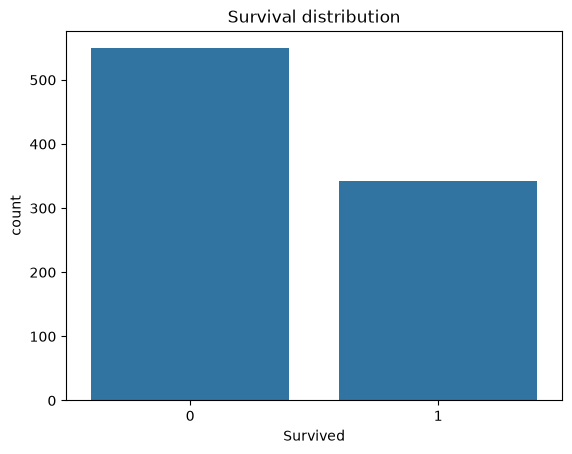

In [48]:
sns.countplot(data=titanic_clean, x='Survived')
plt.title('Survival distribution')
plt.show()

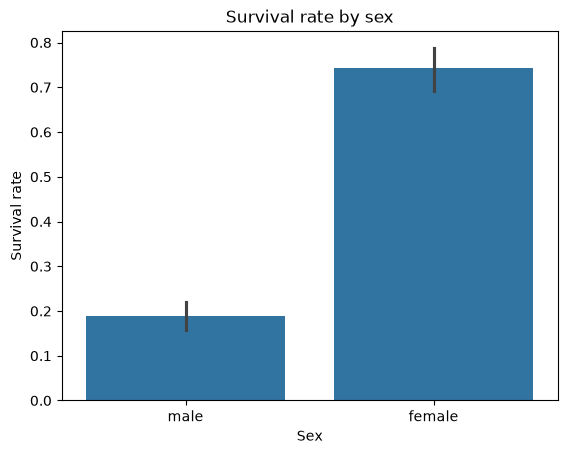

In [50]:
sns.barplot(data=titanic_clean, x='Sex', y='Survived')
plt.title('Survival rate by sex')
plt.ylabel('Survival rate')
plt.show()

Wniosek: więcej kobiet przezyło

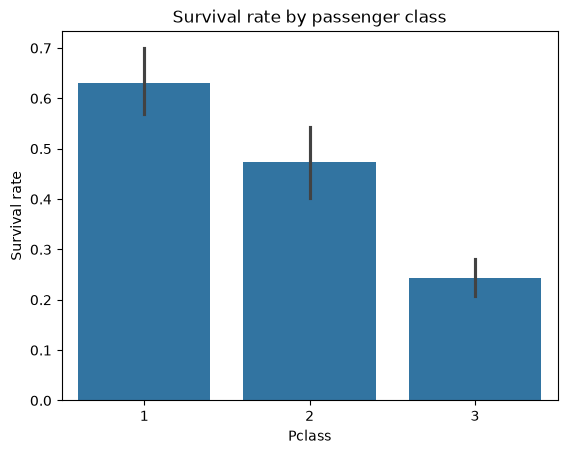

In [52]:
sns.barplot(data=titanic_clean, x='Pclass', y='Survived')
plt.title('Survival rate by passenger class')
plt.ylabel('Survival rate')
plt.show()

Wniosek: lepsza klasa, miała znaczenie przy przezyciu

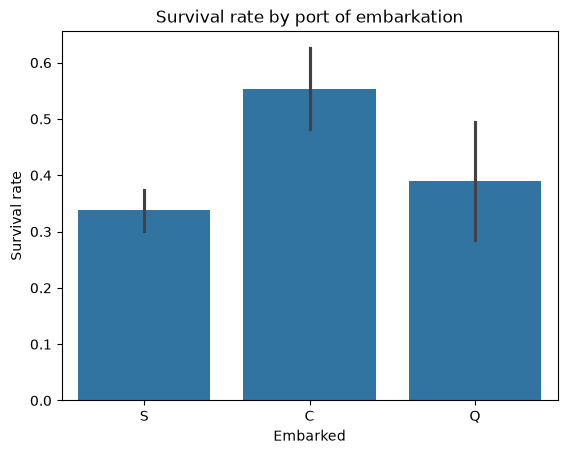

In [53]:
sns.barplot(data=titanic_clean, x='Embarked', y='Survived')
plt.title('Survival rate by port of embarkation')
plt.ylabel('Survival rate')
plt.show()

Więcej osób z Cherbourg przezyło. Dlaczego? Czyzby więcej osób stamtąd miało wyzszą klasę?

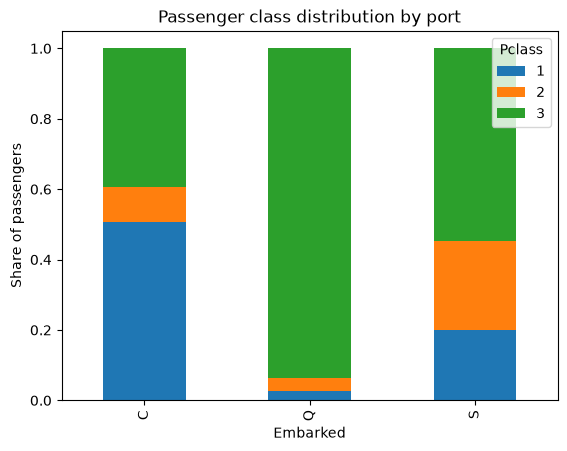

In [77]:
class_share = pd.crosstab(
    titanic_clean['Embarked'],
    titanic_clean['Pclass'],
    normalize='index'
)

class_share.plot(
    kind='bar',
    stacked=True
)

plt.title('Passenger class distribution by port')
plt.ylabel('Share of passengers')
plt.show()

Graph above explains why so many people from cherburng lived

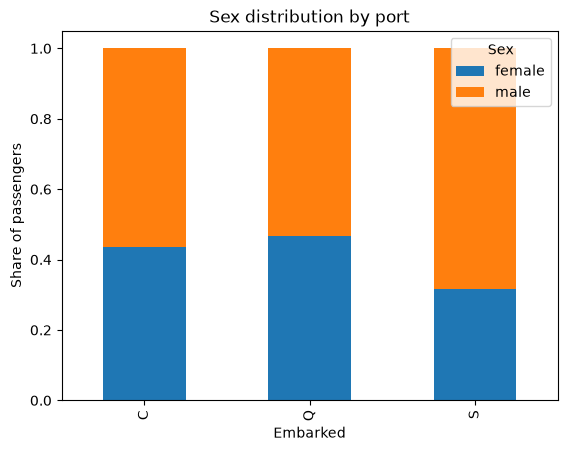

In [78]:
sex_share = pd.crosstab(
    titanic_clean['Embarked'],
    titanic_clean['Sex'],
    normalize='index'
)

sex_share.plot(
    kind='bar',
    stacked=True
)

plt.title('Sex distribution by port')
plt.ylabel('Share of passengers')
plt.show()

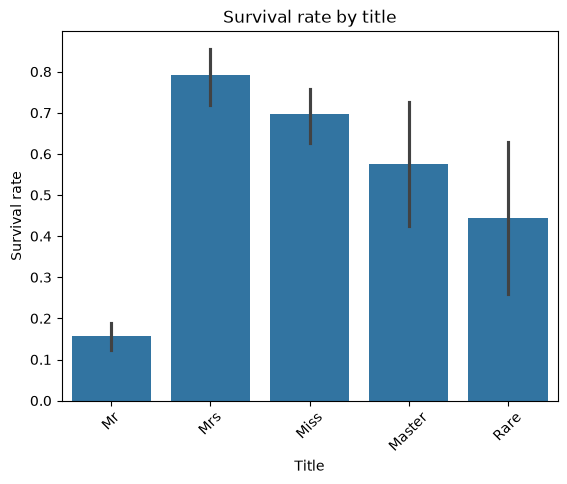

In [55]:
sns.barplot(data=titanic_clean, x='Title', y='Survived')
plt.title('Survival rate by title')
plt.ylabel('Survival rate')
plt.xticks(rotation=45)
plt.show()

Tytuł miał znaczenie

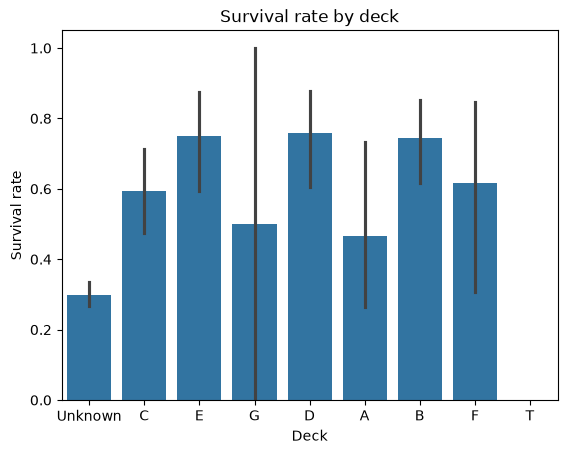

In [56]:
sns.barplot(data=titanic_clean, x='Deck', y='Survived')
plt.title('Survival rate by deck')
plt.ylabel('Survival rate')
plt.show()

To wynika prawdopodobnie z tego, ze informacje o deckach, mamy od bogatszych pasazerów. ale ma znaczenie to czy deck jest unknown czy nie

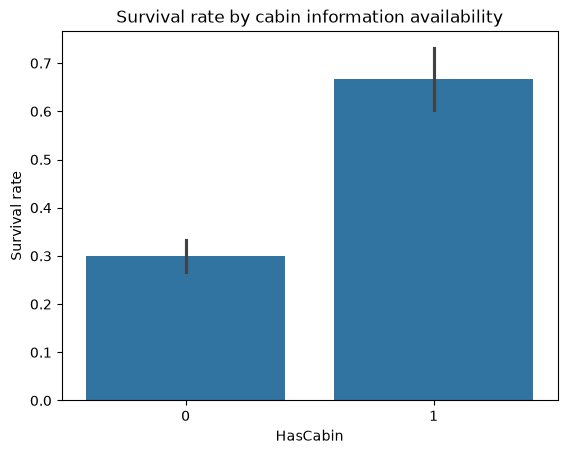

In [57]:
sns.barplot(data=titanic_clean, x='HasCabin', y='Survived')
plt.title('Survival rate by cabin information availability')
plt.ylabel('Survival rate')
plt.show()

Wniosek: informacja o kabinie, ma znaczenie

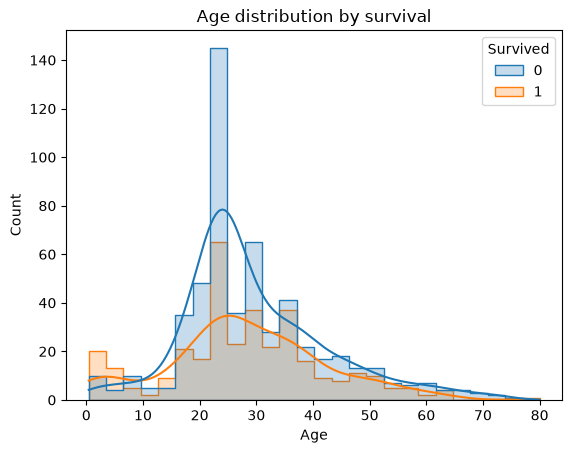

In [58]:
sns.histplot(
    data=titanic_clean,
    x='Age',
    hue='Survived',
    kde=True,
    element='step'
)

plt.title('Age distribution by survival')
plt.show()

Potencjalne: więcej dzieci przezyło procentowo

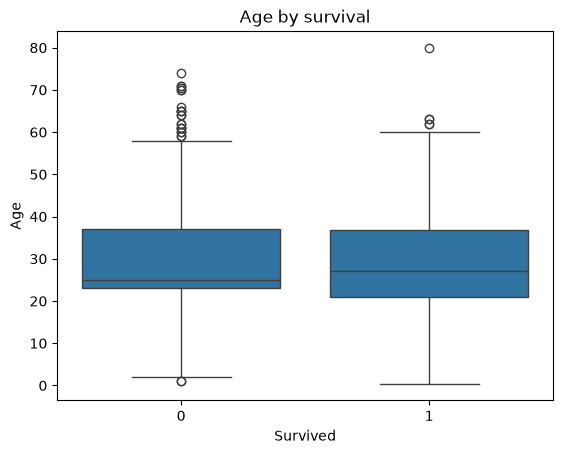

In [59]:
sns.boxplot(data=titanic_clean, x='Survived', y='Age')
plt.title('Age by survival')
plt.show()

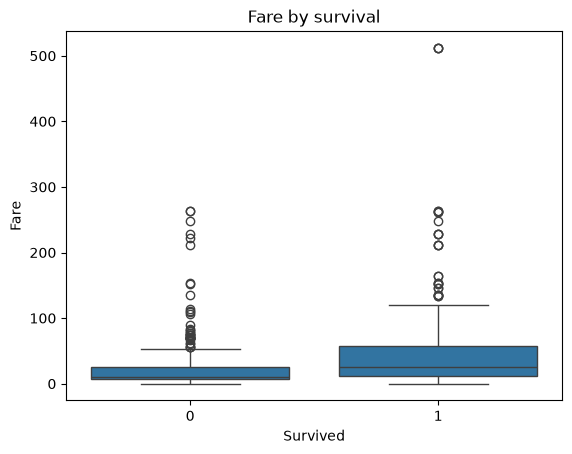

In [60]:
sns.boxplot(data=titanic_clean, x='Survived', y='Fare')
plt.title('Fare by survival')
plt.show()

Wniosek: osoby które płaciły więcej, więcej ich przezyło. Przeskalowane, lepiej widać:

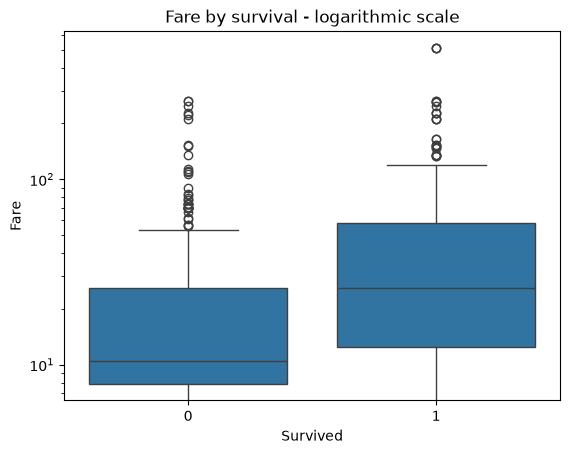

In [61]:
sns.boxplot(data=titanic_clean, x='Survived', y='Fare')
plt.yscale('log')
plt.title('Fare by survival - logarithmic scale')
plt.show()

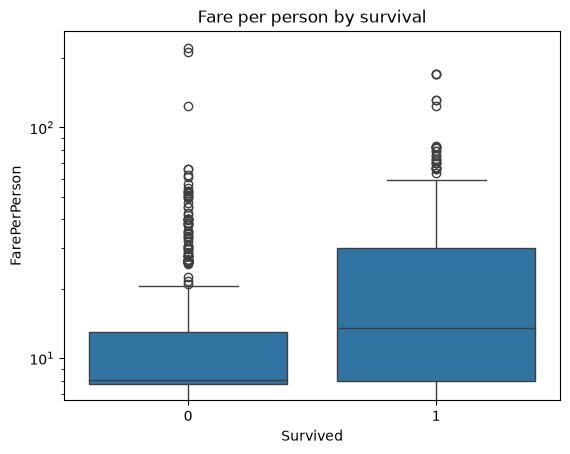

In [62]:
sns.boxplot(data=titanic_clean, x='Survived', y='FarePerPerson')
plt.title('Fare per person by survival')
plt.yscale('log')
plt.show()

Fare per person to potwierdza

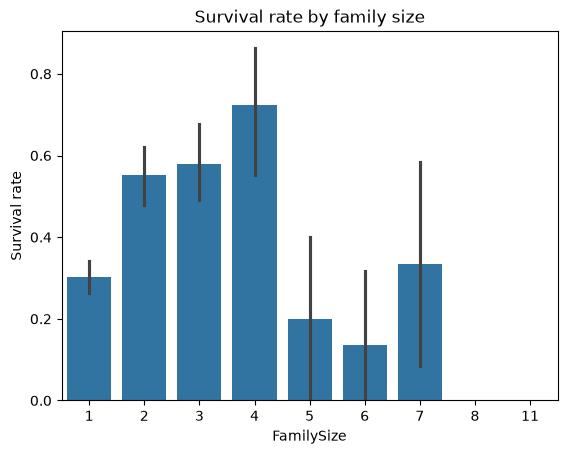

In [63]:
sns.barplot(data=titanic_clean, x='FamilySize', y='Survived')
plt.title('Survival rate by family size')
plt.ylabel('Survival rate')
plt.show()

In [64]:
titanic_df['FamilySize'].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Potencjalny wniosek: Osoby ktore na pokladzie mialy od 2-4 czlonkow mialy wyzsze szanse na przezycie niz inni

In [80]:
pd.crosstab(
    titanic_clean['FamilySize'],
    titanic_clean['Sex'],
    normalize='index'
)

Sex,female,male
FamilySize,,
1,0.234637,0.765363
2,0.540373,0.459627
3,0.480392,0.519608
4,0.655172,0.344828
5,0.800000,0.200000
6,0.363636,0.636364
7,0.666667,0.333333
8,0.333333,0.666667
11,0.428571,0.571429


In [81]:
pd.crosstab(
    titanic_clean['FamilySize'],
    titanic_clean['Pclass'],
    normalize='index'
)

Pclass,1,2,3
FamilySize,,,
1,0.202980,0.193669,0.603352
2,0.434783,0.211180,0.354037
3,0.235294,0.303922,0.460784
4,0.241379,0.448276,0.310345
5,0.133333,0.066667,0.800000
6,0.181818,0.045455,0.772727
7,0.000000,0.000000,1.000000
8,0.000000,0.000000,1.000000
11,0.000000,0.000000,1.000000


rodziny powyzej 4, podrózowaly nie 1. klasą, a dodatkowo dla familysize większej niz 1, jest duzo dzieci i kobiet, co tłumaczy ten fenomen

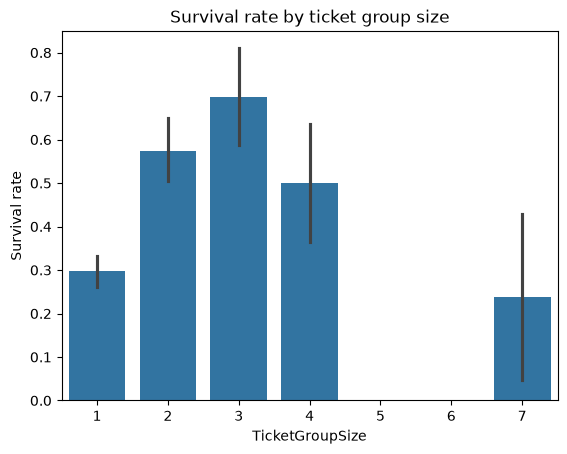

In [65]:
sns.barplot(data=titanic_clean, x='TicketGroupSize', y='Survived')
plt.title('Survival rate by ticket group size')
plt.ylabel('Survival rate')
plt.show()

Powiązane z wielkością rodziny

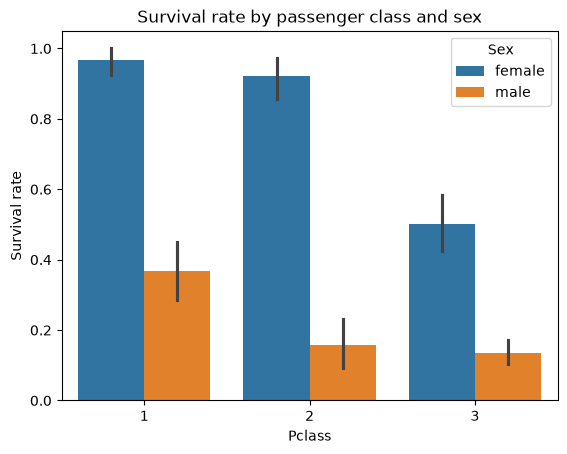

In [66]:
sns.barplot(
    data=titanic_clean,
    x='Pclass',
    y='Survived',
    hue='Sex'
)

plt.title('Survival rate by passenger class and sex')
plt.ylabel('Survival rate')
plt.show()

Przewaga kobiet w przezyciu występowała w kazdej klasie

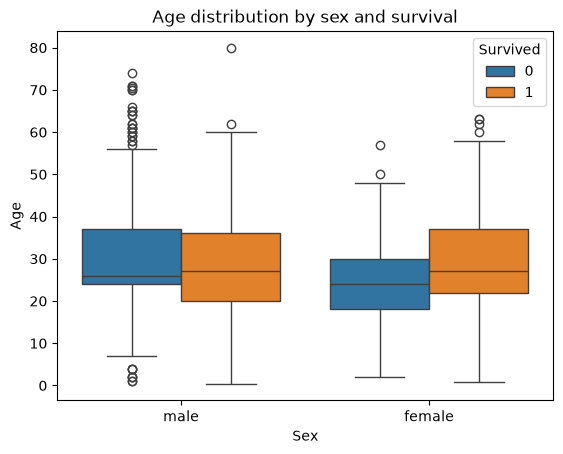

In [67]:
sns.boxplot(
    data=titanic_clean,
    x='Sex',
    y='Age',
    hue='Survived'
)

plt.title('Age distribution by sex and survival')
plt.show()

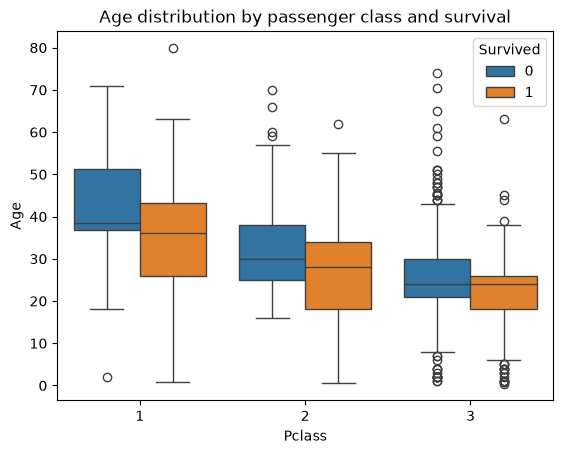

In [68]:
sns.boxplot(
    data=titanic_clean,
    x='Pclass',
    y='Age',
    hue='Survived'
)

plt.title('Age distribution by passenger class and survival')
plt.show()

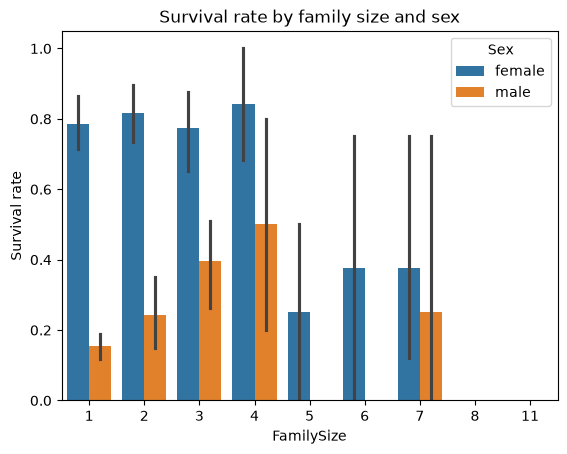

In [69]:
sns.barplot(
    data=titanic_clean,
    x='FamilySize',
    y='Survived',
    hue='Sex'
)

plt.title('Survival rate by family size and sex')
plt.ylabel('Survival rate')
plt.show()

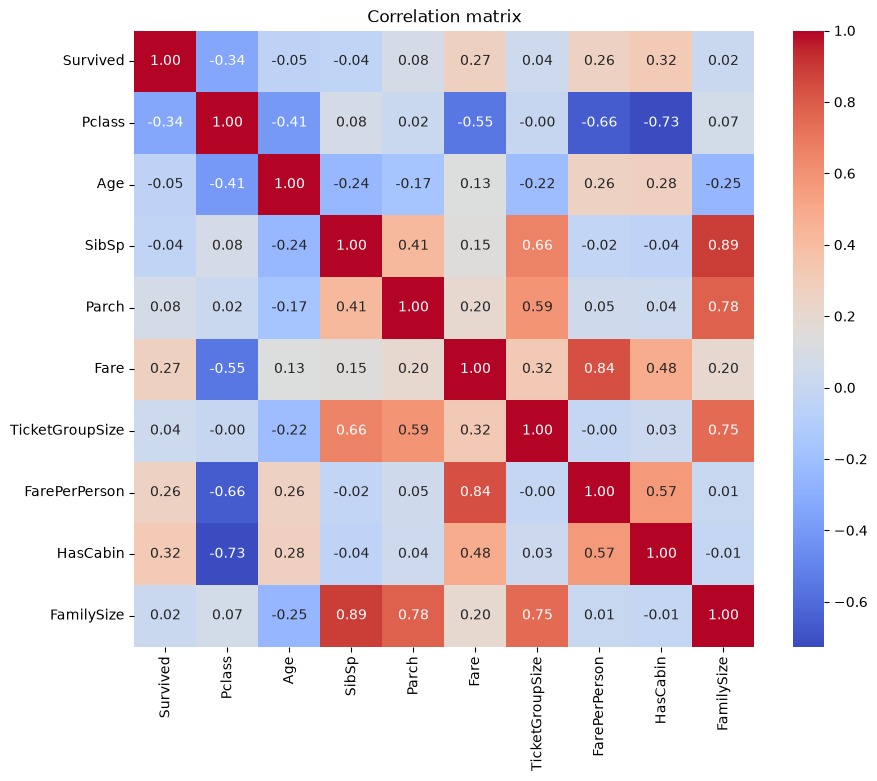

In [76]:
numeric_cols = [
    'Survived',
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'TicketGroupSize',
    'FarePerPerson',
    'HasCabin',
    'FamilySize',
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    titanic_clean[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation matrix')
plt.show()

Wpływ:

PClass -> hascabin

PClass -> fare

## Wnioski z analizy

Najsilniejszy związek z przeżyciem na Titanicu miały:

- **płeć** – kobiety przeżywały znacznie częściej niż mężczyźni,
- **wiek** – dzieci miały wyższe szanse przeżycia niż dorośli,
- **klasa pasażerska (`Pclass`)** – pasażerowie wyższych klas przeżywali częściej niż pasażerowie 3. klasy.

Pozostałe cechy, takie jak `Embarked`, `Fare`, `FamilySize`, `Deck` czy `HasCabin`, również wykazywały zależność z przeżyciem, jednak przynajmniej część tych zależności można wyjaśnić ich powiązaniem z płcią, wiekiem lub klasą pasażerską.

Dlatego na podstawie przeprowadzonego EDA można uznać `Sex`, `Age` i `Pclass` za najważniejsze podstawowe cechy związane z przeżyciem. Nie oznacza to jednak jeszcze, że pozostałe zmienne nie wnoszą dodatkowej informacji po uwzględnieniu tych trzech czynników.